In [33]:
import joblib
import shap
import pandas as pd

X_test = pd.read_csv('processed/X_test.csv')
model = joblib.load('processed/lgbm_model.pkl')

# SHAP works perfectly with LightGBM
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:500])

print(type(shap_values))
print(len(shap_values))

<class 'numpy.ndarray'>
500


C:\Users\adity\anaconda3\envs\loanproject\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  objective_name_map = {


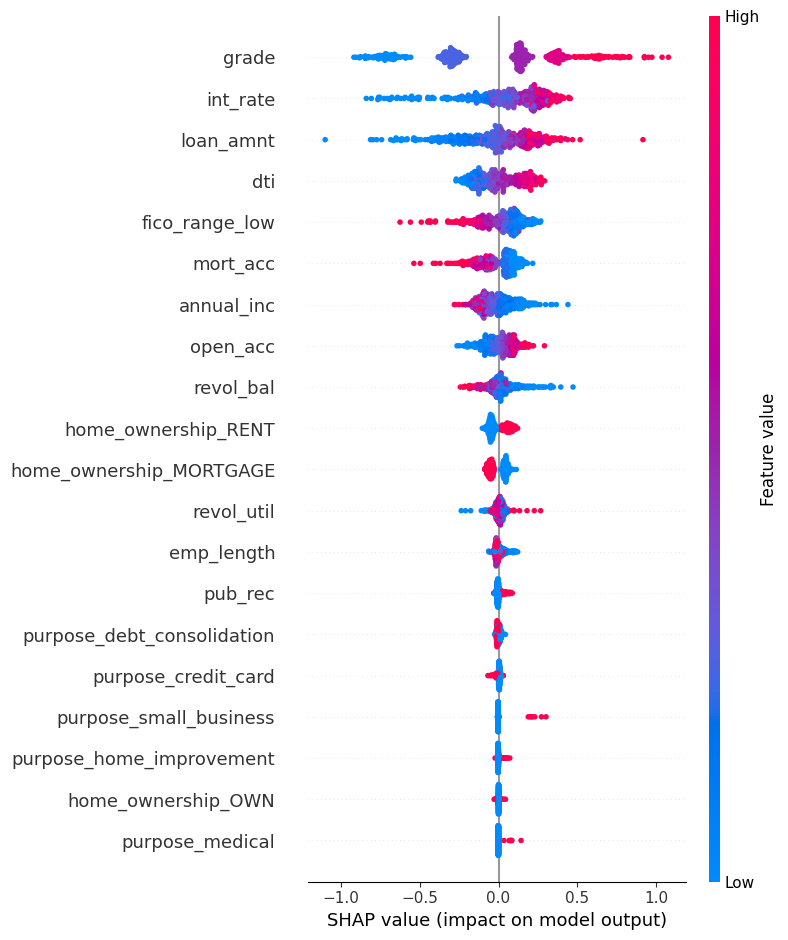

In [34]:
# Global summary plot
shap.summary_plot(shap_values, X_test[:500])

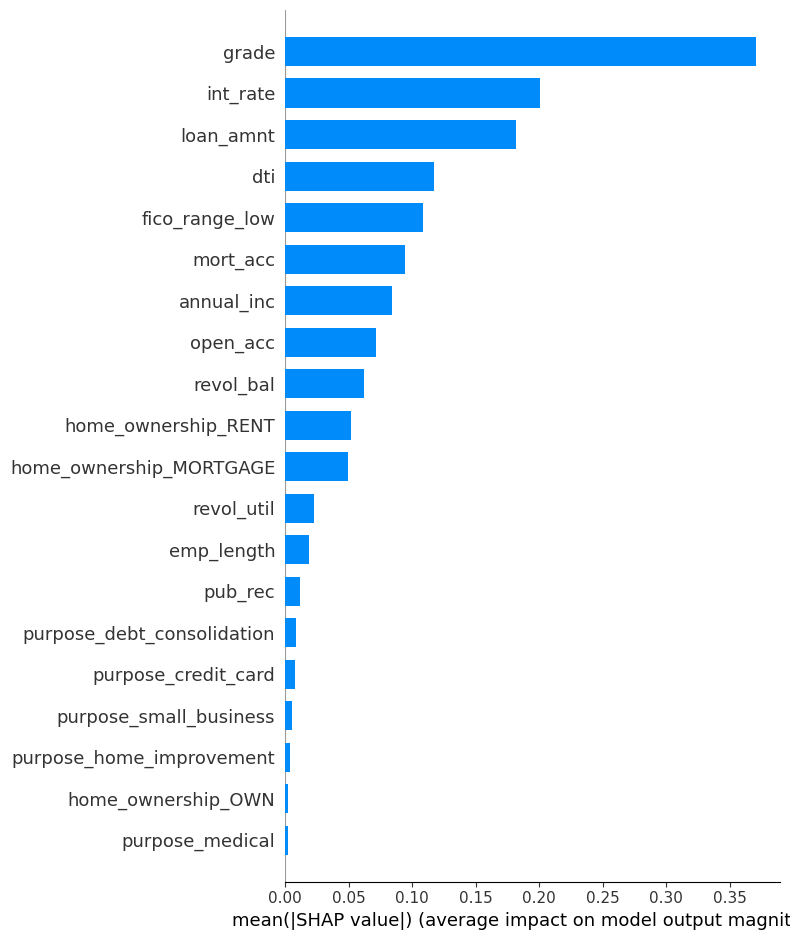

In [41]:
# Bar plot
shap.summary_plot(shap_values, X_test[:500], plot_type="bar")

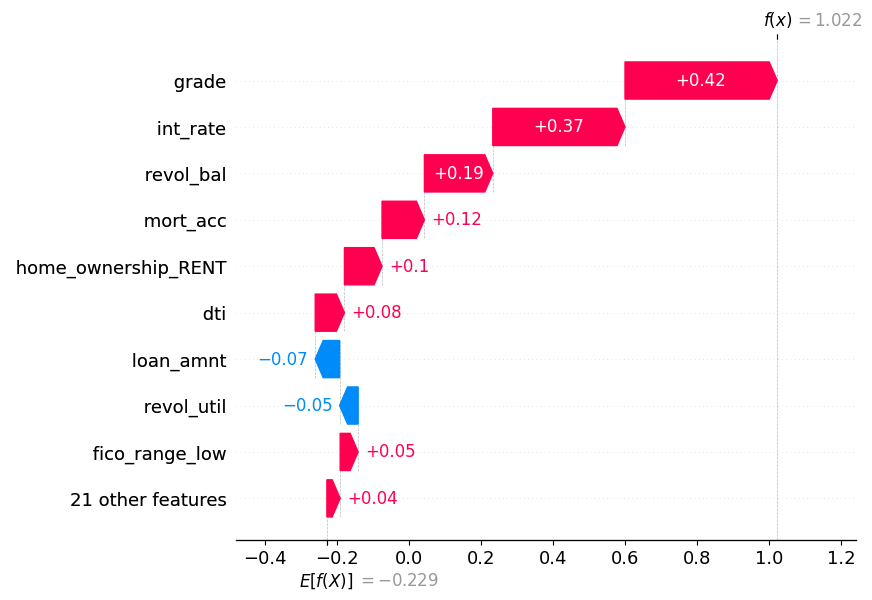

In [43]:
# Local waterfall for first prediction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test[:500].iloc[0]
)